In [2]:
import sys
import os

# Add project root to path so `src_py` is importable as a package
_root = os.path.normpath(os.path.join(os.path.abspath(''), '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import matplotlib.pyplot as plt

from src_py import surrogate_model as surr, muvec as surr_grid
from src_py import surrogate_model_proj as surr_proj


In [3]:
surr_res = surr(4, 1.0, 2.5)
surr_proj_res = surr_proj(0.0, 4, 1.0, 2.5)

mu_max = 10
Nmu = 20
surr_proj_grid = np.linspace(0, mu_max, Nmu)

GYRAZE converged for α=4, γ=1.0, φ=2.5
GYRAZE converged for α=4, γ=1.0, φ=2.5


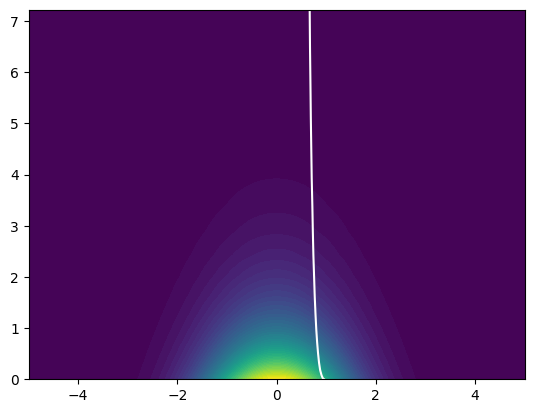

In [4]:
# Define a maxwellian distribution function
def maxwellian(v, mu):
    return np.exp(-0.5 * v**2 - mu)

vvec = np.linspace(-5, 5, 100)

vv, mm = np.meshgrid(vvec, surr_grid)
zz = maxwellian(vv, mm)

figure, ax = plt.subplots()

ax.contourf(vv, mm, zz, levels=50, cmap='viridis')
ax.plot(surr_res, surr_grid, label='alpha=10, gamma=1.0', color='white')

plt.show()

In [5]:
from src_py import generate_c_code

generate_c_code(
    nn_model      = "../model/nn_model.pth",
    svm_model     = "../model/svm_model.pkl",
    normalization = "../model/normalization.npz",
    output_dir    = "../generated_c_code"
)


Generated ../generated_c_code/surrogate.c, ../generated_c_code/surrogate.h, ../generated_c_code/test_surrogate.c, ../generated_c_code/Makefile
Build: cd ../generated_c_code && make


In [6]:
import subprocess
import numpy as np

# --- Run the compiled C test program and capture output ---
proc = subprocess.run(
    ["./test_surrogate"],
    cwd="../generated_c_code",
    capture_output=True, text=True
)
c_out = np.array([
    float(line.split("=")[1])
    for line in proc.stdout.strip().splitlines()
])

# --- Python reference (same inputs as test_surrogate.c: alpha=4, gamma=1.0, phi=2.5) ---
py_out = surr(4, 1.0, 2.5)

# --- Comparison ---
abs_err = np.abs(c_out - py_out)
print(f"{'i':>3}  {'C output':>14}  {'Python output':>14}  {'abs error':>12}")
print("-" * 50)
for i, (c, p, e) in enumerate(zip(c_out, py_out, abs_err)):
    print(f"{i:>3}  {c:>14.8f}  {p:>14.8f}  {e:>12.2e}")

print(f"\nMax absolute error : {abs_err.max():.2e}")
print(f"Mean absolute error: {abs_err.mean():.2e}")


GYRAZE converged for α=4, γ=1.0, φ=2.5
  i        C output   Python output     abs error
--------------------------------------------------
  0      0.94023600      0.95824194      1.80e-02
  1      0.90706200      0.93155932      2.45e-02
  2      0.87663600      0.90539694      2.88e-02
  3      0.84075400      0.87797809      3.72e-02
  4      0.82046000      0.85601616      3.56e-02
  5      0.79894100      0.83643699      3.75e-02
  6      0.78129500      0.81733346      3.60e-02
  7      0.76497900      0.79962289      3.46e-02
  8      0.75032300      0.78392541      3.36e-02
  9      0.73338500      0.76873887      3.54e-02
 10      0.71985300      0.75606501      3.62e-02
 11      0.70987900      0.74181437      3.19e-02
 12      0.69570900      0.73072910      3.50e-02
 13      0.68660100      0.72102940      3.44e-02
 14      0.67680700      0.70807326      3.13e-02
 15      0.66389300      0.69913113      3.52e-02
 16      0.65742300      0.68988001      3.25e-02
 17      0